In [14]:
pip install sionna tensorflow

Note: you may need to restart the kernel to use updated packages.


### 1. Imports

In [15]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import torch
from typing import Dict, Any

import sionna
from sionna.phy.ofdm.demodulator import OFDMDemodulator

# Import the core logic and configuration from our separated python module
from sionna_dg import (
    SimConfig,
    expj,
    simulate_full_frames_tf,
    generate_dataset_offline,
    classical_receiver_with_phi_cfo,
    classical_receiver
)

### 2. Globals, hyperparameters, devices

In [16]:
DATA_PATH = "./data/radio_data.pth"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Device: {DEVICE}")

base_cfg_dict = dict(
    num_examples=3000,
    bits_per_symbol=4,
    k=256,
    demap_method="app",
    dec_num_iter=15,
    cn_update="minsum",
    seed=46,
    channels_last=True,
    cfo_mode="direct",
    cfo_norm_min=-2e-4,
    cfo_norm_max=+2e-4,
    ebn0_db_min=0.0,
    ebn0_db_max=12.0,
    llr_noise_scaling=1.0,
    pilot_bits_per_symbol=2,
    include_pilot_overhead_in_no=True,
    include_cp_overhead_in_no=True,
)

# Single-carrier config
cfg_sc = SimConfig(**{
    **base_cfg_dict,
    "waveform": "sc",
    "seq_length": 128,
    "pilot_len": 8,
})

# OFDM config
cfg_ofdm = SimConfig(**{
    **base_cfg_dict,
    "waveform": "ofdm",
    "seq_length": 128,              
    "ofdm_fft_size": 64,
    "ofdm_cp_len": 16,
    "ofdm_num_pilot_symbols": 1,
    "ofdm_num_data_symbols": 2,
    "ofdm_l_min": 0,
})

Using Device: cpu


### 3. Utils and helpers

In [17]:
def classical_receiver_oracle(cfg: SimConfig, full: Dict[str, Any]) -> Dict[str, Any]:
    """Oracle CFO/CPE (uses true phi0 and cfo_norm) for baseline comparisons."""
    phi_true = tf.cast(full["phi0"], cfg.tf_rdtype)
    cfo_true = tf.cast(full["cfo_norm"], cfg.tf_rdtype)
    return classical_receiver_with_phi_cfo(cfg, full, phi_true, cfo_true)

### 4. Evaluation and prints (Classical Receivers & Reports)

In [18]:
def report_blocks(cfg: SimConfig, num_blocks: int = 10, ebn0_db: float = 4.0, oracle: bool = False):
    """Print per-sample diagnostics for fixed Eb/N0."""
    cfgb = SimConfig(**{
        **cfg.__dict__,
        "num_examples": int(num_blocks),
        "ebn0_db_min": float(ebn0_db),
        "ebn0_db_max": float(ebn0_db),
        "seed": int(cfg.seed),
        "seed_noise": int(cfg.seed_noise) if cfg.seed_noise is not None else int(cfg.seed + 999),
    })

    full = simulate_full_frames_tf(cfgb)
    rx = classical_receiver_oracle(cfgb, full) if oracle else classical_receiver(cfgb, full)

    info_bits = full["info_bits"].numpy().astype(np.uint8)
    info_hat = rx["info_bits_hat"].numpy().astype(np.uint8)
    coded_bits = full["coded_bits"].numpy().astype(np.uint8)
    llr = rx["llr"].numpy()
    hard_coded = (llr > 0).astype(np.uint8)

    print("---- PER-SAMPLE REPORT ----")
    print(f"waveform={full['meta'].get('waveform')} | oracle={oracle}")

    for i in range(num_blocks):
        no = float(full["no"].numpy()[i, 0])
        ebn0 = float(full["ebn0_db"].numpy()[i])
        phi0 = float(full["phi0"].numpy()[i, 0])
        cfo = float(full["cfo_norm"].numpy()[i, 0])

        err_c = int(np.sum(hard_coded[i] != coded_bits[i]))
        ber_pre = err_c / coded_bits.shape[1]

        err_u = int(np.sum(info_hat[i] != info_bits[i]))
        ber_post = err_u / info_bits.shape[1]
        bler_post = 1 if err_u > 0 else 0

        print(f"\nSample #{i}")
        print(f"  Eb/N0 (info-bit) : {ebn0:6.2f} dB")
        print(f"  no (complex var) : {no:.3e}")
        print(f"  phi0 true        : {phi0:+.3f} rad")
        print(f"  CFO true         : {cfo:+.6e}  ({full['meta'].get('cfo_unit','')})")
        print(f"  PRE  coded BER   : {ber_pre:.3e}   (err={err_c}/{coded_bits.shape[1]})")
        print(f"  POST info  BER   : {ber_post:.3e}  BLER={bler_post} (err={err_u}/{info_bits.shape[1]})")

### 5. Plots

In [19]:
def plot_ber_bler_vs_ebn0(base_cfg: SimConfig, ebn0_grid_db, n_per_point: int = 3000):
    ber_pre, ber_post, bler_post = [], [], []

    for idx, e in enumerate(ebn0_grid_db):
        cfg_e = SimConfig(**{
            **base_cfg.__dict__,
            "num_examples": int(n_per_point),
            "ebn0_db_min": float(e),
            "ebn0_db_max": float(e),
            "seed": int(base_cfg.seed),
            "seed_noise": int(base_cfg.seed + 10_000 + idx),  
        })

        full = simulate_full_frames_tf(cfg_e)
        rx = classical_receiver(cfg_e, full)

        m = rx["metrics"]
        ber_pre.append(m["ber_pre_coded"])
        ber_post.append(m["ber_post_info"])
        bler_post.append(m["bler_post_info"])

        print(f"Eb/N0={float(e):5.1f} dB | "
              f"preBER={m['ber_pre_coded']:.3e} | "
              f"postBER={m['ber_post_info']:.3e} | "
              f"BLER={m['bler_post_info']:.3e}")

    plt.figure()
    plt.semilogy(ebn0_grid_db, ber_pre, marker="o")
    plt.grid(True, which="both")
    plt.xlabel("Eb/N0 [dB] (info-bit)")
    plt.ylabel("BER pre-decoder (coded)")
    plt.title(f"Pre-decoder BER vs Eb/N0 | waveform={base_cfg.waveform}")

    plt.figure()
    plt.semilogy(ebn0_grid_db, ber_post, marker="o")
    plt.grid(True, which="both")
    plt.xlabel("Eb/N0 [dB] (info-bit)")
    plt.ylabel("BER post-decoder (info)")
    plt.title(f"Post-decoder BER vs Eb/N0 | waveform={base_cfg.waveform}")

    plt.figure()
    plt.semilogy(ebn0_grid_db, bler_post, marker="o")
    plt.grid(True, which="both")
    plt.xlabel("Eb/N0 [dB] (info-bit)")
    plt.ylabel("BLER post-decoder")
    plt.title(f"Post-decoder BLER vs Eb/N0 | waveform={base_cfg.waveform}")

    plt.show()

def plot_constellation_example(cfg: SimConfig, ebn0_db: float = 6.0, idx: int = 0, max_points: int = 256):
    """Plots clean vs RX data constellation for a given Eb/N0."""
    cfg1 = SimConfig(**{
        **cfg.__dict__,
        "num_examples": max(1, idx + 1),
        "ebn0_db_min": float(ebn0_db),
        "ebn0_db_max": float(ebn0_db),
        "seed": int(cfg.seed),
        "seed_noise": int(cfg.seed_noise) if cfg.seed_noise is not None else None,
    })

    full = simulate_full_frames_tf(cfg1)
    meta = full["meta"]
    waveform = meta.get("waveform", "sc")

    x = full["x_data"].numpy()[idx] 

    if waveform == "sc":
        P = int(meta["P"])
        y_full = full["y_rx"].numpy()[idx]
        y = y_full[P:] 

    elif waveform == "ofdm":
        fft_size = int(meta["fft_size"])
        cp_len = int(meta["cp_len"])
        n_pilot_sym = int(meta["num_pilot_ofdm_symbols"])
        l_min = int(meta.get("ofdm_l_min", 0))

        y_rx = full["y_rx"][idx:idx+1]  
        phi0 = full["phi0"][idx:idx+1]
        cfo  = full["cfo_norm"][idx:idx+1]
        T = int(meta["T"])

        t = tf.cast(tf.range(T)[None, :], cfg.tf_rdtype)
        phi_total = tf.cast(phi0, cfg.tf_rdtype) + tf.constant(2.0*np.pi, cfg.tf_rdtype) * tf.cast(cfo, cfg.tf_rdtype) * t
        y_corr = y_rx * expj(-phi_total, cfg.tf_cdtype)

        demod = OFDMDemodulator(fft_size=fft_size, l_min=l_min, cyclic_prefix_length=cp_len)
        y_grid = demod(y_corr)  
        y_data = y_grid[:, n_pilot_sym:, :]
        y = tf.reshape(y_data, [1, -1]).numpy()[0]  

    else:
        raise ValueError(f"Unknown waveform={waveform}")

    take = min(len(x), int(max_points))
    x = x[:take]
    y = y[:take]

    plt.figure()
    plt.scatter(np.real(x), np.imag(x), s=10)
    plt.grid(True); plt.axis("equal")
    plt.title(f"CLEAN data constellation | {waveform} | Eb/N0={ebn0_db} dB | sample #{idx}")

    plt.figure()
    plt.scatter(np.real(y), np.imag(y), s=10)
    plt.grid(True); plt.axis("equal")
    plt.title(f"RX data constellation | {waveform} | Eb/N0={ebn0_db} dB | sample #{idx}")

    plt.show()

### 9. Execution Block: Generate datasets + Evaluate baselines + Save to DATA_PATH

Sionna version: 1.2.1

Running waveform: sc
Metrics (estimated): {'ber_pre_coded': 0.1074029952287674, 'ber_post_info': 0.08010416477918625, 'bler_post_info': 0.40566667914390564}
Metrics (oracle)   : {'ber_pre_coded': 0.09368880093097687, 'ber_post_info': 0.06659114360809326, 'bler_post_info': 0.35600000619888306}
Eb/N0=  0.0 dB | preBER=2.311e-01 | postBER=2.546e-01 | BLER=1.000e+00
Eb/N0=  1.0 dB | preBER=2.067e-01 | postBER=2.357e-01 | BLER=1.000e+00
Eb/N0=  2.0 dB | preBER=1.823e-01 | postBER=2.141e-01 | BLER=1.000e+00
Eb/N0=  3.0 dB | preBER=1.601e-01 | postBER=1.839e-01 | BLER=9.870e-01
Eb/N0=  4.0 dB | preBER=1.379e-01 | postBER=1.092e-01 | BLER=7.687e-01
Eb/N0=  5.0 dB | preBER=1.165e-01 | postBER=3.589e-02 | BLER=2.950e-01
Eb/N0=  6.0 dB | preBER=9.678e-02 | postBER=1.061e-02 | BLER=8.633e-02
Eb/N0=  7.0 dB | preBER=7.885e-02 | postBER=3.628e-03 | BLER=3.200e-02
Eb/N0=  8.0 dB | preBER=6.100e-02 | postBER=5.677e-04 | BLER=5.000e-03
Eb/N0=  9.0 dB | preBER=4.659e-02 | postBER=

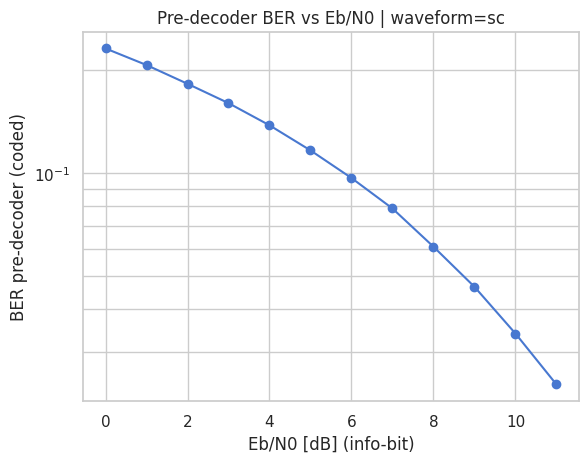

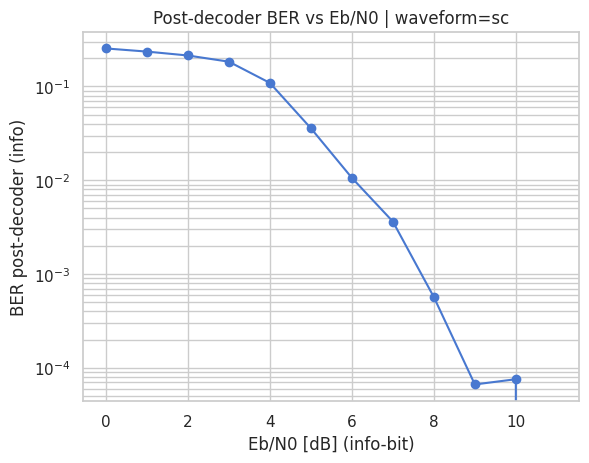

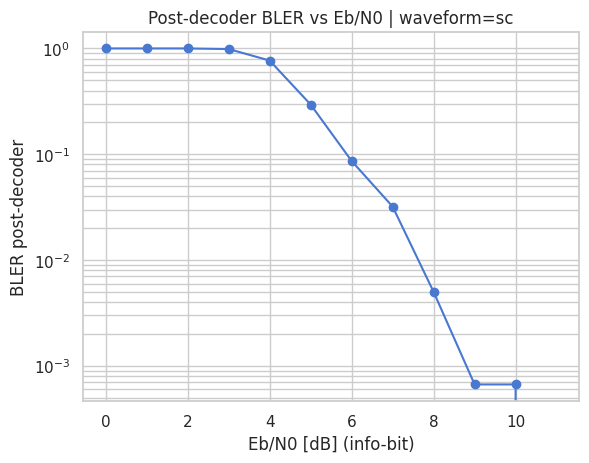


Running waveform: ofdm
Metrics (estimated): {'ber_pre_coded': 0.15844270586967468, 'ber_post_info': 0.13880988955497742, 'bler_post_info': 0.6066666841506958}
Metrics (oracle)   : {'ber_pre_coded': 0.14297395944595337, 'ber_post_info': 0.12179297208786011, 'bler_post_info': 0.5516666769981384}
Eb/N0=  0.0 dB | preBER=2.975e-01 | postBER=3.028e-01 | BLER=1.000e+00
Eb/N0=  1.0 dB | preBER=2.721e-01 | postBER=2.847e-01 | BLER=1.000e+00
Eb/N0=  2.0 dB | preBER=2.462e-01 | postBER=2.655e-01 | BLER=1.000e+00
Eb/N0=  3.0 dB | preBER=2.210e-01 | postBER=2.472e-01 | BLER=1.000e+00
Eb/N0=  4.0 dB | preBER=1.962e-01 | postBER=2.269e-01 | BLER=1.000e+00
Eb/N0=  5.0 dB | preBER=1.729e-01 | postBER=2.034e-01 | BLER=1.000e+00
Eb/N0=  6.0 dB | preBER=1.491e-01 | postBER=1.531e-01 | BLER=9.330e-01
Eb/N0=  7.0 dB | preBER=1.273e-01 | postBER=6.777e-02 | BLER=5.287e-01
Eb/N0=  8.0 dB | preBER=1.074e-01 | postBER=2.146e-02 | BLER=1.707e-01
Eb/N0=  9.0 dB | preBER=8.705e-02 | postBER=5.646e-03 | BLER=4.70

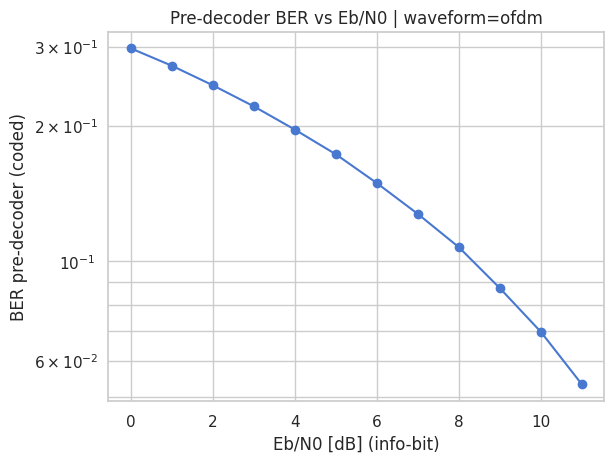

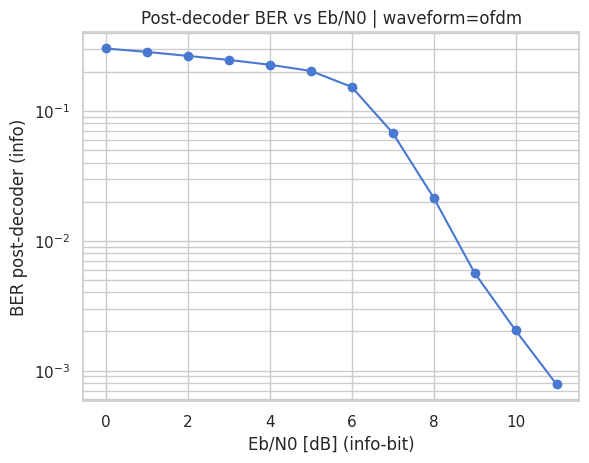

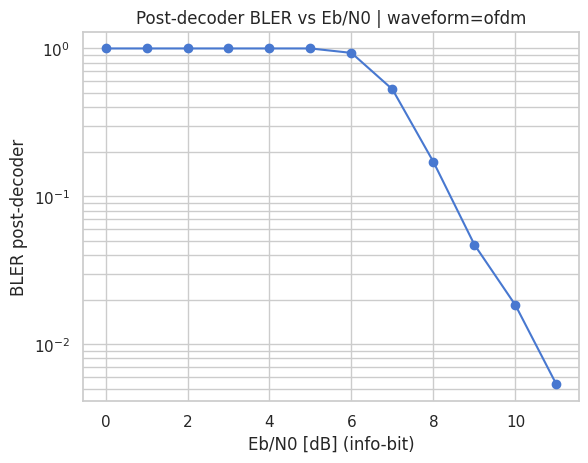


Generating and saving datasets to ./data/radio_data.pth ...
Saved datasets to ./data/radio_data.pth


In [20]:
if __name__ == "__main__":
    print("Sionna version:", getattr(sionna, "__version__", "unknown"))

    for cfg in [cfg_sc, cfg_ofdm]:
        print("\n===============================")
        print("Running waveform:", cfg.waveform)

        full_tf = simulate_full_frames_tf(cfg)
        rx = classical_receiver(cfg, full_tf)
        rx_or = classical_receiver_oracle(cfg, full_tf)

        print("Metrics (estimated):", rx["metrics"])
        print("Metrics (oracle)   :", rx_or["metrics"])

        ebn0_grid_db = list(range(0, 12))
        plot_ber_bler_vs_ebn0(cfg, ebn0_grid_db, n_per_point=3000)

    # --- Create dataset(s) and save to DATA_PATH ---
    os.makedirs(os.path.dirname(DATA_PATH), exist_ok=True)
    print(f"\nGenerating and saving datasets to {DATA_PATH} ...")

    ds_sc = generate_dataset_offline(cfg_sc)
    ds_ofdm = generate_dataset_offline(cfg_ofdm)

    # Save both datasets in a single .pth file
    torch.save({"sc": ds_sc, "ofdm": ds_ofdm}, DATA_PATH)
    print(f"Saved datasets to {DATA_PATH}")